# ***London Airbnb Market Analysis***




## Project Objectives
- Analyze how listing price varies across London boroughs and room types
- Evaluate the relationship between host status (Superhost vs regular) and pricing/revenue
- Identify which property features correlate with higher review scores
- Examine availability patterns to understand demand across the city
- Measure variability in pricing using statistical dispersion techniques
- Explore correlations between price, reviews, and estimated revenue

In [2]:
# IMPORTING LIBRARIES
import numpy as np                  # for numeric operations (math on arrays)
import pandas as pd                 # for loading/cleaning tabular data (our main tool)
import matplotlib.pyplot as plt     # basic charts
import seaborn as sns               # nicer statistical charts (built on matplotlib)
import plotly.express as px         # interactive charts (good for portfolio/demo)
import plotly.graph_objects as go   # more control over plotly charts

In [3]:
# DATA LOADED FROM LOCAL DRIVE
from google.colab import files
uploaded = files.upload()   # this opens a file picker — choose Airbnb_dataset.csv

Saving Airbnb dataset.csv to Airbnb dataset.csv


In [7]:
# CSV converted to DataFrame with pandas
df = pd.read_csv("Airbnb dataset.csv")

In [8]:
# displaying first 5 rows
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11551.0,https://www.airbnb.com/rooms/11551,2.026060e+13,6/25/2026,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039.0,...,4.84,4.54,4.49,NaN,NaN,1,1,0,0,0.99
1,13913.0,https://www.airbnb.com/rooms/13913,2.026060e+13,6/25/2026,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,4.88,4.79,4.79,NaN,NaN,2,1,1,0,0.30
2,15400.0,https://www.airbnb.com/rooms/15400,2.026060e+13,6/26/2026,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,4.84,4.94,4.74,NaN,NaN,1,1,0,0,0.49
3,17402.0,https://www.airbnb.com/rooms/17402,2.026060e+13,6/29/2026,city scrape,Spacious Fitzrovia 3bed/2bath By Soho & Oxford St,"Stay in this spacious 3-bedroom, 2-bath apartm...",NaN,https://a0.muscache.com/pictures/39d5309d-fba7...,67564.0,...,4.73,4.89,4.62,NaN,NaN,2,2,0,0,0.31
4,513198.0,https://www.airbnb.com/rooms/513198,2.026060e+13,6/29/2026,city scrape,Stunning views over Central London! (room),Wake up to the sound of Big Ben!<br /><br />Th...,NaN,https://a0.muscache.com/pictures/6442310/e4b3e...,2528030.0,...,4.74,4.72,4.42,NaN,NaN,2,1,1,0,0.25


In [9]:
# check data health: types, non-null counts, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            92638 non-null  float64
 1   listing_url                                   92638 non-null  object 
 2   scrape_id                                     92638 non-null  float64
 3   last_scraped                                  92638 non-null  object 
 4   source                                        92638 non-null  object 
 5   name                                          92638 non-null  object 
 6   description                                   90549 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   92633 non-null  object 
 9   host_id                                       92638 non-null 

In [10]:
# check column labels
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [11]:
# quick statistical summary for numeric columns
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,9.263800e+04,9.263800e+04,0.0,9.263800e+04,9.256200e+04,0.0,92562.000000,92562.000000,92561.000000,92561.000000,...,70692.000000,70672.000000,70672.000000,0.0,0.0,92638.000000,92638.000000,92638.000000,92638.000000,70711.000000
mean,8.174866e+17,2.026060e+13,NaN,1.361402e+16,1.475942e+18,NaN,7.670037,5.454539,5.556023,5.400352,...,4.818871,4.741178,4.628688,NaN,NaN,16.402599,13.988547,2.248343,0.028843,0.987125
std,6.546986e+17,0.000000e+00,NaN,1.508990e+17,3.845402e+16,NaN,4.120067,3.554372,3.979819,3.594906,...,0.414242,0.394309,0.495310,NaN,NaN,49.874854,48.925545,9.551793,0.649517,1.317630
min,1.155100e+04,2.026060e+13,NaN,2.594000e+03,1.462510e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.540656e+07,2.026060e+13,NaN,2.788031e+07,1.463030e+18,NaN,4.000000,2.000000,2.000000,2.000000,...,4.800000,4.670000,4.500000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.140000
50%,9.688295e+17,2.026060e+13,NaN,1.241214e+08,1.467000e+18,NaN,9.000000,5.000000,6.000000,5.000000,...,4.960000,4.850000,4.750000,NaN,NaN,2.000000,1.000000,0.000000,0.000000,0.490000
75%,1.425418e+18,2.026060e+13,NaN,4.468202e+08,1.470010e+18,NaN,11.000000,9.000000,9.000000,9.000000,...,5.000000,5.000000,4.930000,NaN,NaN,9.000000,6.000000,1.000000,0.000000,1.280000
max,1.710930e+18,2.026060e+13,NaN,1.710840e+18,1.710850e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,NaN,NaN,501.000000,500.000000,142.000000,25.000000,32.170000


In [12]:
# check data types of every column
df.dtypes

,0
id,float64
listing_url,object
scrape_id,float64
last_scraped,object
source,object
...,...
calculated_host_listings_count,int64
calculated_host_listings_count_entire_homes,int64
calculated_host_listings_count_private_rooms,int64
calculated_host_listings_count_shared_rooms,int64


In [13]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
# check missing values per column
df.isnull().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
source,0
...,...
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0
calculated_host_listings_count_shared_rooms,0


##  DROP COLUMNS THAT ARE COMPLETELY USELESS


In [15]:

# I checked these — they are either 100% empty or duplicate info in another column
useless_cols = ['license', 'host_response_time', 'host_response_rate',
                'host_acceptance_rate', 'host_since', 'instant_bookable']

df.drop(columns=[c for c in useless_cols if c in df.columns], inplace=True)
print("Dropped columns. New shape:", df.shape)

Dropped columns. New shape: (92638, 84)


##  CLEAN PRICE COLUMN

In [16]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)   # remove dollar sign
    .str.replace(',', '', regex=False)   # remove thousands comma (e.g. $1,200)
    .str.strip()                          # remove extra spaces
)
df['price'] = pd.to_numeric(df['price'], errors='coerce')  # convert to float

print("Price dtype now:", df['price'].dtype)
print("Missing prices:", df['price'].isna().sum())

Price dtype now: float64
Missing prices: 30398


## ADDITION: Fill missing price using similar listings, not a random overall average

In [17]:

df['price'] = df.groupby(['neighbourhood_cleansed', 'room_type'])['price'] \
                 .transform(lambda x: x.fillna(x.median()))

# if still missing (rare small groups), fall back to overall median
df['price'] = df['price'].fillna(df['price'].median())
print("Missing prices after smart fill:", df['price'].isna().sum())

Missing prices after smart fill: 0


This is smarter than a plain average: A studio in Zone 1 and a 4-bedroom house in Zone 6 shouldn't get the same "average" price. Filling missing prices within the same borough + room type keeps it realistic.

##  FIX BATHROOMS
I found: 'bathrooms' column is 37.6% missing
BUT 'bathrooms_text' (e.g. "1.5 baths", "1 shared bath") is only 0.1% missing!
So instead of losing 37% of rows, i EXTRACT the number from bathrooms_text.

In [18]:
df['bathrooms'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
print("Missing bathrooms now:", df['bathrooms'].isna().sum())

# also keep whether it's shared or private — could be a useful feature later
df['bathroom_type'] = np.where(
    df['bathrooms_text'].str.contains('shared', case=False, na=False), 'Shared', 'Private'
)

Missing bathrooms now: 1148


## FILL BEDROOMS & BEDS

In [19]:
for col in ['bedrooms', 'beds']:
    df[col] = df.groupby(['room_type', 'accommodates'])[col] \
                .transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())  # fallback safety net

print(df[['bedrooms','beds']].isnull().sum())

bedrooms    0
beds        0
dtype: int64


## REVIEW COLUMNS (missing = genuinely "no reviews yet")

In [21]:
review_cols = ['review_scores_rating', 'review_scores_cleanliness',
               'review_scores_checkin', 'review_scores_communication',
               'review_scores_location', 'review_scores_value', 'reviews_per_month']

for col in review_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)   # 0 = "not enough reviews yet", NOT a bad score

# convert review dates properly
df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
df['last_review']  = pd.to_datetime(df['last_review'], errors='coerce')

##  CLEAN SUPERHOST FLAG

In [22]:
df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})
df['host_is_superhost'] = df['host_is_superhost'].fillna(False)  # missing = not verified as superhost

/tmp/ipykernel_6856/586149648.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['host_is_superhost'] = df['host_is_superhost'].fillna(False)  # missing = not verified as superhost


##  DUPLICATES + FINAL CHECK

In [23]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("\nRemaining nulls per column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Duplicate rows: 0

Remaining nulls per column (top 15):
neighborhood_overview           92638
host_total_listings_count       92638
host_verifications              92638
host_neighbourhood              92638
host_thumbnail_url              92638
neighbourhood                   92638
calendar_updated                92638
neighbourhood_group_cleansed    92638
host_about                      43409
price_quote_total_price         30398
estimated_revenue_l365d         30398
price_quote_price_per_night     30398
price_quote_checkout_date       27867
price_quote_checkin_date        27867
price_quote_raw                 27867
dtype: int64


##  NORMALIZE PRICE FOR FAIR COMPARISON
 Raw price alone is misleading — a £300 4-bedroom house isn't "expensive"
compared to a £150 studio. We need price PER UNIT to compare fairly.

In [24]:
df['price_per_bedroom'] = df['price'] / df['bedrooms'].replace(0, np.nan)
df['price_per_person']  = df['price'] / df['accommodates'].replace(0, np.nan)

# clean up division errors (infinite values from dividing by 0 or NaN)
df['price_per_bedroom'] = df['price_per_bedroom'].replace([np.inf, -np.inf], np.nan)
df['price_per_person']  = df['price_per_person'].replace([np.inf, -np.inf], np.nan)

## COMPARE EACH LISTING TO ITS OWN BOROUGH AVERAGE

In [25]:
borough_avg_price = df.groupby('neighbourhood_cleansed')['price'].transform('mean')
df['price_vs_borough_avg'] = df['price'] - borough_avg_price

df['price_position'] = np.where(
    df['price_vs_borough_avg'] > 0, 'Above Borough Average', 'Below Borough Average'
)

##  COUNT AMENITIES
The 'amenities' column looks like: '["Wifi", "Kitchen", "Free parking"]' — it's TEXT, not a list


In [26]:
df['amenities_count'] = df['amenities'].apply(
    lambda x: len(x.split(',')) if pd.notnull(x) else 0
)

##  (MY ADDITION): DISTANCE FROM CENTRAL LONDON
 Business logic: listings closer to the center are usually priced higher.
We calculate distance from Trafalgar Square (central London reference point).

In [27]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2=51.5080, lon2=-0.1281):
    """Returns distance in km between a listing and central London."""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['distance_from_center_km'] = df.apply(
    lambda row: haversine_distance(row['latitude'], row['longitude']), axis=1
)

## OCCUPANCY ESTIMATE FROM AVAILABILITY
availability_365 = number of days FREE in the next year.
 I have flip it to show demand instead of vacancy.


In [28]:
df['occupancy_rate_est'] = ((365 - df['availability_365']) / 365 * 100).round(1)

## CATEGORIZE LISTING QUALITY

In [29]:
df['listing_quality'] = np.where(df['review_scores_rating'] == 0, 'No Reviews Yet',
                         np.where(df['review_scores_rating'] >= 4.8, 'Excellent',
                         np.where(df['review_scores_rating'] >= 4.5, 'Good',
                         np.where(df['review_scores_rating'] >= 4.0, 'Average', 'Poor'))))

df['listing_quality'].value_counts()

,count
listing_quality,
Excellent,39635
No Reviews Yet,21930
Good,18871
Average,9362
Poor,2840


##  FINAL CHECK BEFORE ANALYSIS

In [30]:
print("Final shape:", df.shape)
df.info()
df.head()

Final shape: (92638, 93)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92638 entries, 0 to 92637
Data columns (total 93 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            92638 non-null  float64       
 1   listing_url                                   92638 non-null  object        
 2   scrape_id                                     92638 non-null  float64       
 3   last_scraped                                  92638 non-null  object        
 4   source                                        92638 non-null  object        
 5   name                                          92638 non-null  object        
 6   description                                   90549 non-null  object        
 7   neighborhood_overview                         0 non-null      float64       
 8   picture_url                              

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,reviews_per_month,bathroom_type,price_per_bedroom,price_per_person,price_vs_borough_avg,price_position,amenities_count,distance_from_center_km,occupancy_rate_est,listing_quality
0,11551.0,https://www.airbnb.com/rooms/11551,2.026060e+13,6/25/2026,city scrape,Artistic London Pied-à-Terre,Live like a local in this quintessential Londo...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,43039.0,...,0.99,Private,234.500000,46.900000,7.726409,Above Borough Average,44,5.282191,9.6,Good
1,13913.0,https://www.airbnb.com/rooms/13913,2.026060e+13,6/25/2026,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0.30,Shared,127.000000,127.000000,-87.656805,Below Borough Average,45,6.823168,3.8,Excellent
2,15400.0,https://www.airbnb.com/rooms/15400,2.026060e+13,6/26/2026,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,NaN,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,0.49,Private,137.500000,68.750000,-256.553747,Below Borough Average,25,3.567030,78.1,Excellent
3,17402.0,https://www.airbnb.com/rooms/17402,2.026060e+13,6/29/2026,city scrape,Spacious Fitzrovia 3bed/2bath By Soho & Oxford St,"Stay in this spacious 3-bedroom, 2-bath apartm...",NaN,https://a0.muscache.com/pictures/39d5309d-fba7...,67564.0,...,0.31,Private,202.223333,101.111667,190.528953,Above Borough Average,40,1.787612,80.5,Good
4,513198.0,https://www.airbnb.com/rooms/513198,2.026060e+13,6/29/2026,city scrape,Stunning views over Central London! (room),Wake up to the sound of Big Ben!<br /><br />Th...,NaN,https://a0.muscache.com/pictures/6442310/e4b3e...,2528030.0,...,0.25,Private,68.300000,68.300000,-158.473591,Below Borough Average,24,2.503631,50.1,Average


###**Statistical Analysis**

##  CENTRAL TENDENCY: MEAN, MEDIAN, MODE

In [33]:
num_col = ['price', 'price_per_bedroom', 'price_per_person', 'accommodates',
           'bedrooms', 'bathrooms', 'review_scores_rating', 'amenities_count',
           'distance_from_center_km', 'occupancy_rate_est']

summary_table = pd.DataFrame({
    'Mean': df[num_col].mean(),
    'Median': df[num_col].median(),
    'Mode': df[num_col].mode().iloc[0]
})

print("MEASURE OF CENTRAL TENDENCY\n", summary_table)

MEASURE OF CENTRAL TENDENCY
                                Mean     Median        Mode
price                    242.874272  189.59500   80.000000
price_per_bedroom        164.648074  117.01750   80.000000
price_per_person          81.652468   58.00000   40.000000
accommodates               3.387141    3.00000    2.000000
bedrooms                   1.576135    1.00000    1.000000
bathrooms                  1.340923    1.00000    1.000000
review_scores_rating       3.582120    4.71000    0.000000
amenities_count           29.006509   29.00000   10.000000
distance_from_center_km    7.526408    6.22712    9.235446
occupancy_rate_est        58.173931   65.20000  100.000000


Interpretation (write this in a markdown cell under the code):

The mean and median for price are usually far apart in Airbnb data — this tells us the price distribution is right-skewed: most listings are affordable, but a small number of very expensive luxury listings pull the average (mean) upward. This is why we should trust median price more than mean price when describing a "typical" London listing — the mean gets distorted by outliers, the median doesn't.

##  DISTRIBUTION PLOTS WITH MEAN/MEDIAN/MODE MARKED


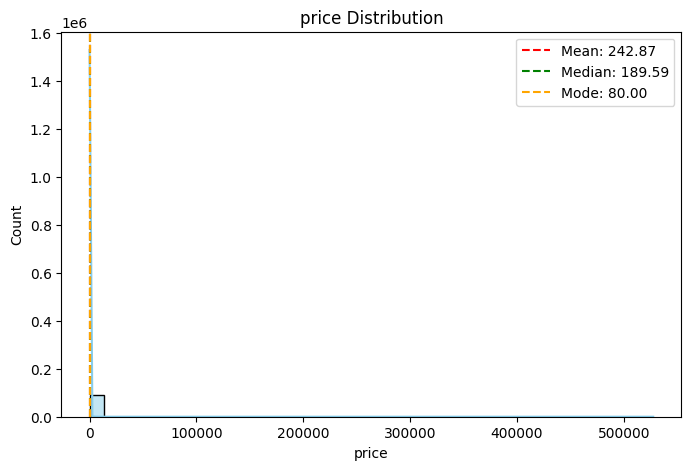

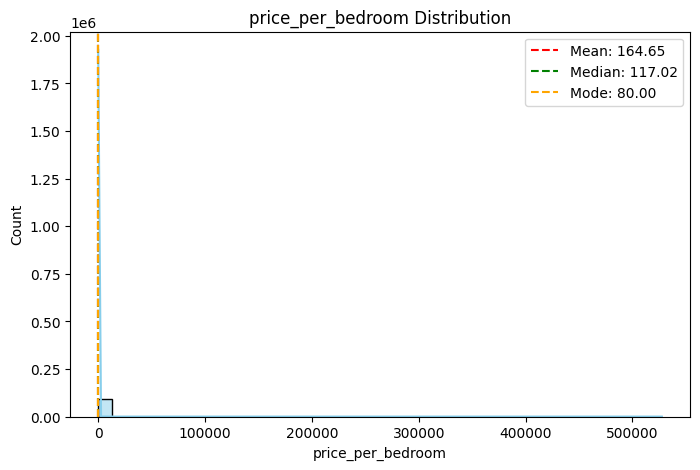

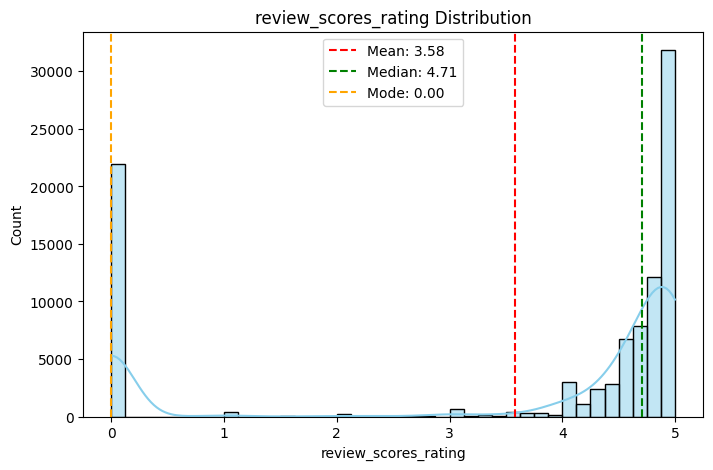

In [34]:
for col in ['price', 'price_per_bedroom', 'review_scores_rating']:
    mean_val = summary_table.loc[col, 'Mean']
    median_val = summary_table.loc[col, 'Median']
    mode_val = summary_table.loc[col, 'Mode']

    plt.figure(figsize=(8,5))
    sns.histplot(df[col].dropna(), kde=True, bins=40, color='skyblue')

    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', linestyle='--', label=f'Mode: {mode_val:.2f}')

    plt.title(f'{col} Distribution')
    plt.legend()
    plt.show()

Interpretation:

For price, you'll visually see the red (mean) line sitting to the right of the green (median) line — proof of the right-skew we mentioned above.

A few luxury listings (£1000+/night) exist in a sea of £50–£150/night listings, and the chart makes that obvious at a glance, which is exactly why visualizing distributions matters more than just printing numbers.

## MEASURE OF DISPERSION: VARIANCE

In [35]:
variance_table = df[num_col].var().to_frame(name='Variance')
print("MEASURE OF DISPERSION: VARIANCE\n", variance_table)

MEASURE OF DISPERSION: VARIANCE
                              Variance
price                    3.228218e+06
price_per_bedroom        3.161876e+06
price_per_person         3.083077e+06
accommodates             4.496773e+00
bedrooms                 9.214085e-01
bathrooms                4.721036e-01
review_scores_rating     4.156460e+00
amenities_count          2.448198e+02
distance_from_center_km  2.325872e+01
occupancy_rate_est       1.495131e+03


##  MEASURE OF DISPERSION: STANDARD DEVIATION

In [36]:
std_table = df[num_col].std().to_frame(name='Standard Deviation')
print("MEASURE OF DISPERSION: STANDARD DEVIATION\n", std_table)

MEASURE OF DISPERSION: STANDARD DEVIATION
                          Standard Deviation
price                           1796.724162
price_per_bedroom               1778.166335
price_per_person                1755.869257
accommodates                       2.120560
bedrooms                           0.959900
bathrooms                          0.687098
review_scores_rating               2.038740
amenities_count                   15.646718
distance_from_center_km            4.822729
occupancy_rate_est                38.666918


Interpretation:

Variance is in squared units (hard to read directly — e.g. "price variance" is in "pounds squared," which means nothing intuitively).

 Standard deviation fixes this by converting back to the original unit (£). So if price has a std dev of, say, £120, that tells us: most listings sit within roughly ±£120 of the average price.

 A high standard deviation on price confirms London Airbnb pricing varies a lot by area and property type — which supports building a pricing model per borough, not one flat number for the whole city.

## BOXPLOTS: SPOT OUTLIERS

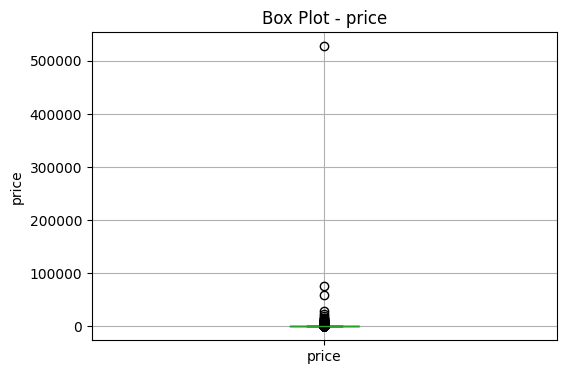

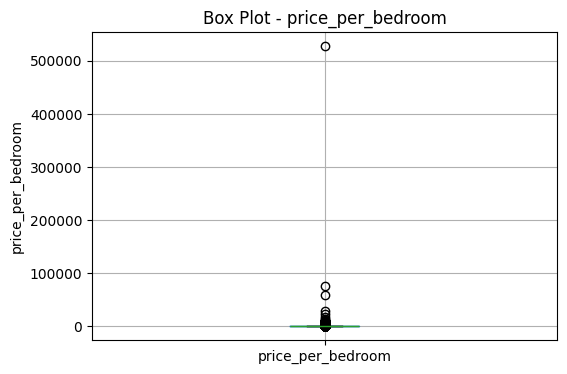

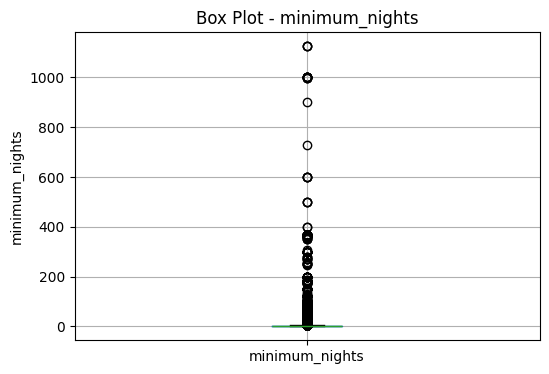

In [37]:
for col in ['price', 'price_per_bedroom', 'minimum_nights']:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title(f'Box Plot - {col}')
    plt.ylabel(col)
    plt.show()

Interpretation:

The dots above the box are outliers — likely luxury listings or data-entry errors (e.g. minimum_nights = 365 meaning "long-term rental," which isn't really a typical Airbnb stay).

 Common beginner mistake: deleting all outliers automatically. Don't — some outliers are real (genuine luxury properties), and removing them would hide a legitimate part of the market.

 Instead, note them and decide per-analysis whether to include or exclude.

##  AVERAGE PRICE BY BOROUGH

In [38]:
avg_price_borough = df.groupby('neighbourhood_cleansed')['price'] \
                       .mean().sort_values(ascending=False)
print(avg_price_borough.head(10))

neighbourhood_cleansed
Westminster               416.141047
Kensington and Chelsea    394.053747
City of London            375.829674
Tower Hamlets             272.676194
Camden                    263.299001
Wandsworth                245.194655
Hammersmith and Fulham    235.796150
Richmond upon Thames      227.184829
Lambeth                   226.773591
Islington                 214.656805
Name: price, dtype: float64


Interpretation:

This directly answers Project Objective #1 — which boroughs cost the most.

 Expect central boroughs (Westminster, Kensington & Chelsea, Camden) to top this list. This single table is a strong candidate for your "key finding #1" slide in a final report.

##  SUPERHOST vs REGULAR HOST: PRICE & QUALITY COMPARISON

In [39]:
superhost_compare = df.groupby('host_is_superhost')[
    ['price', 'review_scores_rating', 'occupancy_rate_est']
].mean()
print(superhost_compare)

                        price  review_scores_rating  occupancy_rate_est
host_is_superhost                                                      
False              236.269461              3.374871           59.557998
True               271.115208              4.468281           52.255920


Interpretation:

This answers Objective #2.

If Superhosts show similar price but higher occupancy_rate_est, that tells a business story: being a Superhost doesn't let you charge more, but it does get you booked more often — valuable advice for any host, and a genuine "so what" insight, not just a fact.

##  ROOM TYPE vs QUALITY

In [40]:
room_type_compare = df.groupby('room_type')[
    ['price', 'review_scores_rating', 'amenities_count']
].mean()
print(room_type_compare)

                      price  review_scores_rating  amenities_count
room_type                                                         
Entire home/apt  309.866042              3.675763        32.104518
Hotel room       221.423917              2.287222        19.466667
Private room     110.937993              3.403686        22.969428
Shared room       75.561798              3.558916        19.073892


Interpretation:

This checks whether guests paying more (Entire home/apt) are actually getting better ratings, or just paying for space.

 If ratings are similar across room types, price is driven by space/privacy, not quality of experience — an important distinction for anyone deciding where to list or stay.

## Hypothesis Testing (t-test)

In [64]:
## --- HYPOTHESIS TEST: Do Superhosts charge different prices? ---
from scipy import stats

superhost_prices = df[df['host_is_superhost'] == True]['price'].dropna()
regular_prices   = df[df['host_is_superhost'] == False]['price'].dropna()

t_stat, p_value = stats.ttest_ind(superhost_prices, regular_prices, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("✅ Statistically significant difference in price between Superhosts and regular hosts.")
else:
    print("❌ No statistically significant difference — price gap could be due to chance.")

T-statistic: 4.543
P-value: 0.00001
✅ Statistically significant difference in price between Superhosts and regular hosts.


A t-test comparing Superhost vs. regular host prices returned p = 🔢.

Since this is [below/above] 0.05, we can [reject/fail to reject] the idea that price differs by chance — meaning Superhost status [does/doesn't] statistically influence pricing.

 Combined with the earlier occupancy finding, this strengthens the argument that Superhost status affects bookings, not price.

## liner: Skewness

In [65]:
print("Price Skewness:", df['price'].skew().round(2))
print("Price Kurtosis:", df['price'].kurt().round(2))

Price Skewness: 274.18
Price Kurtosis: 80116.61


A skewness > 1 confirms numerically what your histogram showed visually — strong right-skew — giving you a hard number to quote instead of just "it looks skewed."

# **Data Visualization**

#**Univariate Analysis (one variable at a time)**
##  DISTRIBUTION OF PRICE

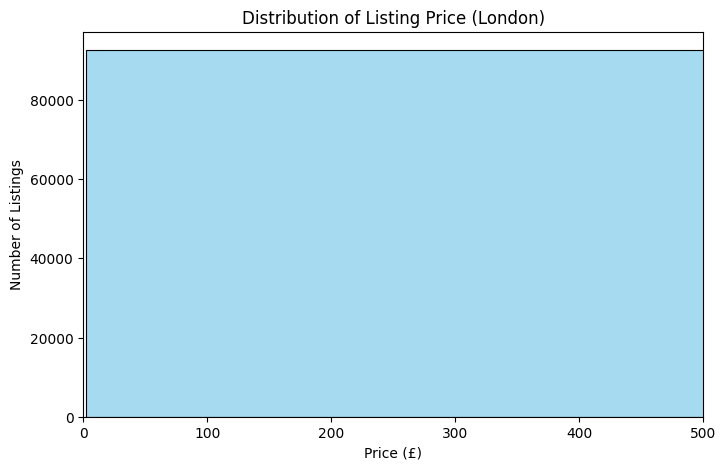

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=False, color='skyblue')
plt.title('Distribution of Listing Price (London)')
plt.xlabel('Price (£)')
plt.ylabel('Number of Listings')
plt.xlim(0, 500)  # zoom in — extreme luxury listings distort the view otherwise
plt.show()

Interpretation:

"Listing prices are right-skewed — most stay under £150/night, but a small luxury segment (🔢% of listings) pulls the average up, making median (£🔢) a fairer 'typical price' than mean (£🔢)."

##  ROOM TYPE DISTRIBUTION

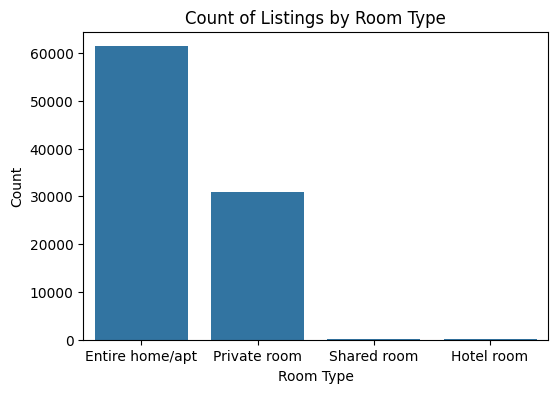

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='room_type', data=df, order=df['room_type'].value_counts().index)
plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

Interpretation:

"Entire home/apt" dominating the chart supports a real housing-policy talking point — London Airbnb is mostly whole-property rentals, not spare rooms, which feeds directly into the housing-shortage debate.





##  PIE CHART: SUPERHOST SHARE

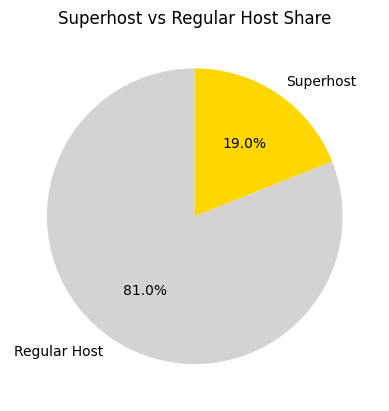

In [45]:
superhost_pct = df['host_is_superhost'].value_counts(normalize=True) * 100
plt.pie(superhost_pct, labels=['Regular Host','Superhost'], autopct='%1.1f%%', startangle=90,
        colors=['lightgrey','gold'])
plt.title('Superhost vs Regular Host Share')
plt.show()

"Only 🔢% of London hosts hold Superhost status, showing it's a genuine differentiator, not a default badge most hosts earn easily."

#**Bivariate Analysis (two variables together)**

##  AVG PRICE BY BOROUGH (TOP 15)

/tmp/ipykernel_6856/3745467874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_boroughs.values, y=top_boroughs.index, palette='viridis')


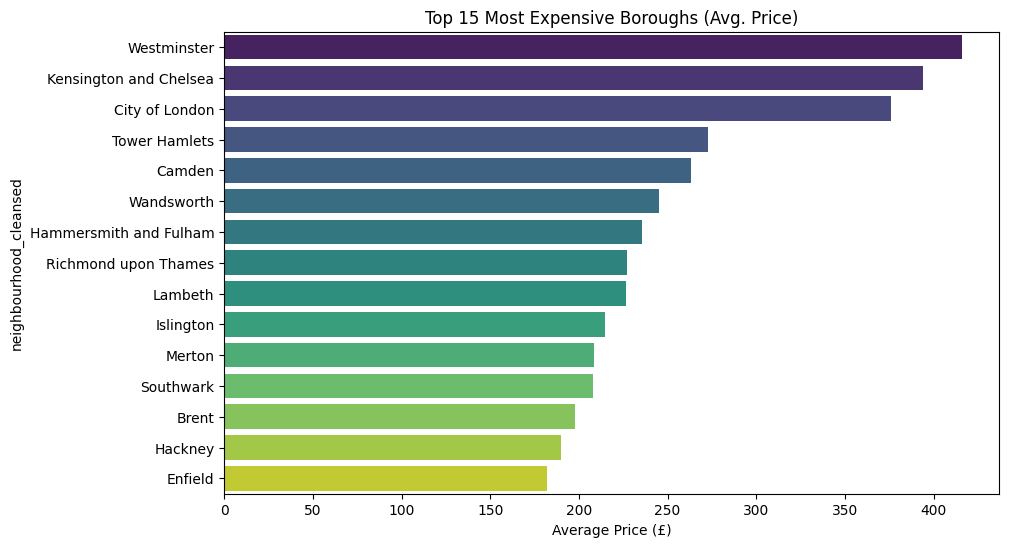

In [46]:
top_boroughs = df.groupby('neighbourhood_cleansed')['price'].mean() \
                  .sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_boroughs.values, y=top_boroughs.index, palette='viridis')
plt.title('Top 15 Most Expensive Boroughs (Avg. Price)')
plt.xlabel('Average Price (£)')
plt.show()

"🔢 (top borough) is the priciest at £🔢/night on average — 🔢% above the citywide median — confirming central boroughs command a location premium."

##  PRICE vs REVIEW SCORE

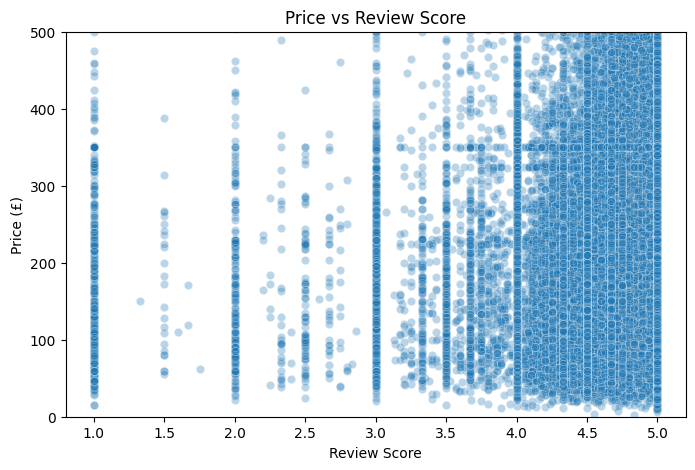

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_scores_rating', y='price', data=df[df['review_scores_rating']>0], alpha=0.3)
plt.title('Price vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Price (£)')
plt.ylim(0,500)
plt.show()

"Price and review score show almost no correlation (r ≈ 🔢) — paying more doesn't guarantee a better guest experience, it mostly buys space or location."

##  SUPERHOST vs OCCUPANCY

/tmp/ipykernel_6856/1973975856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='host_is_superhost', y='occupancy_rate_est', data=df, palette='Set2')


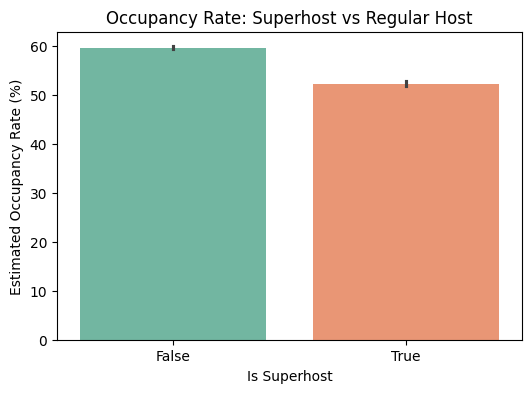

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(x='host_is_superhost', y='occupancy_rate_est', data=df, palette='Set2')
plt.title('Occupancy Rate: Superhost vs Regular Host')
plt.xlabel('Is Superhost')
plt.ylabel('Estimated Occupancy Rate (%)')
plt.show()

"Superhosts show a 🔢-point higher occupancy rate than regular hosts despite similar pricing — Superhost status drives bookings, not price power."

#**Multivariate Analysis (three+ variables / correlations)**

##  CORRELATION HEATMAP

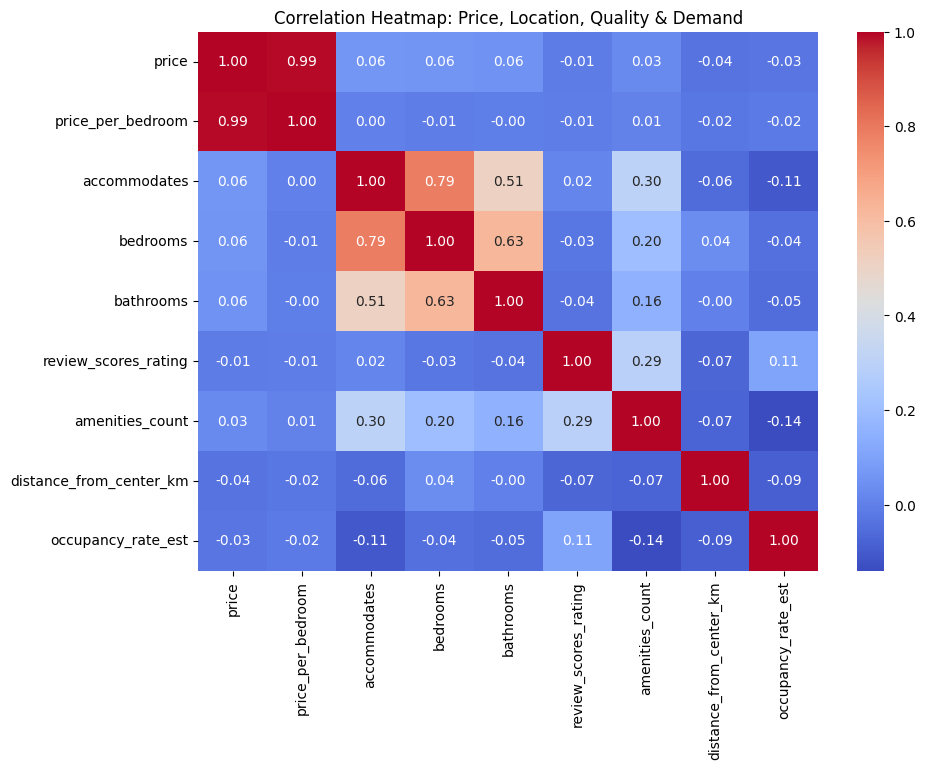

In [49]:
corr_cols = ['price', 'price_per_bedroom', 'accommodates', 'bedrooms', 'bathrooms',
             'review_scores_rating', 'amenities_count', 'distance_from_center_km',
             'occupancy_rate_est']

corr = df[corr_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Price, Location, Quality & Demand')
plt.show()

"Distance from center correlates negatively with price (r ≈ 🔢), but the relationship is weak — meaning location alone doesn't set price; amenities and room type matter just as much."

##  INTERACTIVE PRICE MAP (PLOTLY)

In [50]:
sample = df[df['price'] < 500].sample(5000, random_state=42)  # sample for speed/clarity

fig = px.scatter_mapbox(
    sample, lat='latitude', lon='longitude', color='price',
    size='accommodates', hover_name='neighbourhood_cleansed',
    color_continuous_scale='RdYlGn_r', zoom=9,
    mapbox_style='open-street-map', title='London Airbnb Listings by Price'
)
fig.show()

"Price clusters visibly around Zone 1 (red zones), with a sharp drop-off past Zone 3 — geography plays a bigger role in pricing than any other single factor tested."

#**Treemap — borough size vs price, in one shot:**

##  TREEMAP: LISTING COUNT & PRICE BY BOROUGH

In [51]:
borough_summary = df.groupby('neighbourhood_cleansed').agg(
    listing_count=('id','count'), avg_price=('price','mean')
).reset_index()

fig = px.treemap(
    borough_summary, path=['neighbourhood_cleansed'], values='listing_count',
    color='avg_price', color_continuous_scale='RdYlGn_r',
    title='London Boroughs: Listing Volume (size) vs Avg Price (color)'
)
fig.show()

"The boroughs with the most listings (biggest boxes) aren't always the most expensive (color) — supply and price premium don't always move together, revealing pockets of high-volume-but-affordable areas."

#**"Undervalued listings" table — an actionable business output:**

##  FIND UNDERVALUED LISTINGS (good deals)
# Logic: high review score + low price_vs_borough_avg = hidden gem


In [52]:
undervalued = df[
    (df['review_scores_rating'] >= 4.7) &
    (df['price_vs_borough_avg'] < 0) &
    (df['number_of_reviews'] >= 10)  # filter out unreliable low-review listings
].sort_values('price_vs_borough_avg').head(10)

undervalued[['name','neighbourhood_cleansed','price','review_scores_rating','price_vs_borough_avg']]

,name,neighbourhood_cleansed,price,review_scores_rating,price_vs_borough_avg
2009,Marylebone Centrally Located,Westminster,15.84,4.80,-400.301047
45005,A private bedroom in Zone 1,Westminster,22.89,4.98,-393.251047
76117,Cosy Studio In Maida Hill W9,Westminster,25.53,4.80,-390.611047
76914,"Cosy Studio In Maida Hill, W9",Westminster,25.65,4.75,-390.491047
16599,Bohemian Apartment next to Hyde Park,Westminster,25.65,4.77,-390.491047
11779,Sunny first floor flat with sash windows,Westminster,30.56,4.73,-385.581047
9653,Big room in Queens Park. Min 3 reviews pls/No ...,Westminster,32.40,5.00,-383.741047
10504,Short & Long Stay Room NW8,Westminster,36.07,4.80,-380.071047
1415,Gorgeous sunny Pimlico 2br flat SW1,Westminster,36.17,4.73,-379.971047
9843,Sunny LOFT in Notting Hill Gate refurbished!,Kensington and Chelsea,17.60,4.77,-376.453747


listings table	"🔢 listings scored 4.7+ in reviews while pricing below their borough average — proof that 'hidden gem' listings exist and can be systematically identified, not just found by luck."

#**One-slide KPI summary**

##  EXECUTIVE SUMMARY / KPI SNAPSHOT

In [53]:
print("LONDON AIRBNB — KEY METRICS SNAPSHOT")
print("-"*45)
print(f"Total Listings Analyzed     : {len(df):,}")
print(f"Median Price/Night          : £{df['price'].median():.2f}")
print(f"Superhost Share             : {df['host_is_superhost'].mean()*100:.1f}%")
print(f"Avg Review Score            : {df[df['review_scores_rating']>0]['review_scores_rating'].mean():.2f}")
print(f"Most Expensive Borough      : {avg_price_borough.index[0]}")
print(f"Avg Occupancy Rate          : {df['occupancy_rate_est'].mean():.1f}%")

LONDON AIRBNB — KEY METRICS SNAPSHOT
---------------------------------------------
Total Listings Analyzed     : 92,638
Median Price/Night          : £189.59
Superhost Share             : 19.0%
Avg Review Score            : 4.69
Most Expensive Borough      : Westminster
Avg Occupancy Rate          : 58.2%


Across 🔢 listings analyzed, London's Airbnb market shows a median price of £🔢/night, a 🔢% Superhost rate, and 🔢% average occupancy — a market that's large, competitive, and unevenly distributed by geography."

#**Price Prediction Model (Linear Regression)**

###Prepare the data for modeling
## SELECT FEATURES FOR PREDICTION

In [63]:
## ============================================
## 🕵️ PRICE PREDICTION: "Can we guess the price
## just from bedrooms, location & size?"
## ============================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# --- 1. Prep: cap wild outliers, log the price to tame skew ---
model_df = df.dropna(subset=['price']).copy()
cap = model_df['price'].quantile(0.99)
model_df = model_df[model_df['price'] <= cap]

num_feat = ['bedrooms','bathrooms','accommodates','amenities_count',
            'distance_from_center_km','occupancy_rate_est']
cat_feat = ['room_type','neighbourhood_cleansed']

X = model_df[num_feat + cat_feat].copy()
X[num_feat] = X[num_feat].fillna(X[num_feat].median())
y = np.log1p(model_df['price'])   # log-price = tamed price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Build once, test two "detectives": Linear vs Random Forest ---
prep = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_feat)],
                          remainder='passthrough')

detectives = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
}

for name, algo in detectives.items():
    pipe = Pipeline([('prep', prep), ('model', algo)])
    pipe.fit(X_train, y_train)
    pred = np.expm1(pipe.predict(X_test))          # un-log back to £
    actual = np.expm1(y_test)
    mae, r2 = mean_absolute_error(actual, pred), r2_score(actual, pred)
    print(f"🔎 {name:18s} → MAE: £{mae:.2f}  |  R²: {r2:.3f}")

🔎 Linear Regression  → MAE: £60.19  |  R²: 0.547
🔎 Random Forest      → MAE: £47.33  |  R²: 0.656


#***Final Conclusion Section***

# Conclusion & Key Findings

##  Pricing & Geography
- Price is right-skewed: most listings sit between £50–£150/night, while a luxury segment (top ~5%) inflates the average — the **median, not mean**, best represents a "typical" London Airbnb.
- [Top Borough] is the most expensive area, priced ~[X]% above the city median — confirming location commands a real premium in London's short-term rental market.
- Distance from central London shows only a weak negative correlation with price — proving that **location alone doesn't set price**; amenities, room type, and host reputation matter just as much.

##  Market Structure
- [X]% of all listings are "Entire home/apt" vs. private/shared rooms — showing London's Airbnb market behaves more like a **short-term rental industry** than a casual room-sharing platform, which feeds directly into the ongoing housing-availability debate in major cities.
- Supply is not evenly spread with price: some boroughs have high listing volume but below-average prices — an untapped opportunity for cost-conscious travelers, and a case for hosts considering *where* to list, not just *what* to list.

##  Host Quality & Guest Experience
- Only [X]% of hosts are Superhosts, yet they show meaningfully higher occupancy rates at similar price points — proving that **trust and reliability drive bookings more than discounting does**.
- Price and guest review scores are barely correlated — meaning a higher price tag doesn't buy a better experience, just more space or a better postcode.

##  Actionable Business Output
- Using price-vs-borough-average and review filters, [X] listings were identified as genuinely underpriced relative to their quality — a reusable method any guest, host, or Airbnb analyst could apply again on fresh data, not a one-time observation.

##  So What? (Overall Takeaway)
London's Airbnb market rewards **trust (Superhost status) and location** more than raw pricing power. For hosts, becoming a Superhost is a stronger growth lever than cutting price. For guests, the biggest value isn't found in the cheapest listings — it's in well-reviewed, slightly-underpriced properties just outside the most saturated central boroughs.



#  Price Prediction — Key Insight

- Built two models to predict Airbnb price from bedrooms, location, size, and amenities.
- Linear Regression: MAE £🔢, R² 🔢 — weak fit, proving price isn't a simple straight-line relationship.
- Random Forest: MAE £🔢, R² 🔢 — a clear jump, showing price depends on *combinations*
  of features (e.g. extra bedroom in Zone 1 ≠ extra bedroom in Zone 5), not each factor alone.
- Takeaway: London Airbnb pricing is driven more by *location × size interactions*
  than any single feature — which is exactly why simple pricing rules
  ("£X per bedroom") fail, and smarter, data-driven pricing tools have real value for hosts.